**TRẦN QUỐC BẢO - MASTIU23001**

# ***Problem Statement***

- The objective of this project is to predict whether a loan will be paid back
based on customer demographic and financial information. This is a binary
classification problem where the target variable indicates loan repayment
status.

- Accurate prediction of loan payback is important for reducing financial risk
and improving decision-making in loan approval processes.


## Import libraries

In [1]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.compose         import ColumnTransformer
from sklearn.pipeline        import Pipeline

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from xgboost                 import XGBClassifier


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report, auc
)

In [2]:
pd.set_option('display.max_columns', None) # This will display all columns in the DataFrame
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 1000)
pd.options.display.float_format = "{:,.2f}".format

# ***Data Overview and Cleaning***

- The dataset contains both numerical and categorical features describing loan
applicants. An initial inspection was performed to understand the structure
of the data, identify missing values, and verify data types.

- Duplicate records were removed where applicable. No rows were removed based
on missing values, as the dataset was sufficiently complete for modeling.


## Data

In [48]:
df = pd.read_csv('loan.csv')
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,"29,367.99",0.08,736,"2,528.42",13.67,Female,Single,High School,Self-employed,Other,C3,1
1,1,"22,108.02",0.17,636,"4,593.10",12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0
2,2,"49,566.20",0.10,694,"17,005.15",9.76,Male,Single,High School,Employed,Debt consolidation,C5,1
3,3,"46,858.25",0.07,533,"4,682.48",16.10,Female,Single,High School,Employed,Debt consolidation,F1,1
4,4,"25,496.70",0.05,665,"12,184.43",10.21,Male,Married,High School,Employed,Other,D1,1


## Update dataset

In [4]:
# Make sure all Object columns are lower case
for col in df.select_dtypes(['object']).columns:
     df[col] = df[col].str.lower()

# Convert some columnns
df.replace(
     {
         'employment_status': {'self-employed': 'self_employed'},
         'education_level'  : {"bachelor's": 'bachelor', "high school": 'high_school', "master's": 'master'}
     },
     inplace=True
)

# Write to csv
df.to_csv('train.csv', index=False)

## Import data

In [5]:
df = pd.read_csv('train.csv')

In [49]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,"29,367.99",0.08,736,"2,528.42",13.67,Female,Single,High School,Self-employed,Other,C3,1
1,1,"22,108.02",0.17,636,"4,593.10",12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0
2,2,"49,566.20",0.10,694,"17,005.15",9.76,Male,Single,High School,Employed,Debt consolidation,C5,1
3,3,"46,858.25",0.07,533,"4,682.48",16.10,Female,Single,High School,Employed,Debt consolidation,F1,1
4,4,"25,496.70",0.05,665,"12,184.43",10.21,Male,Married,High School,Employed,Other,D1,1


In [7]:
# View dataset total observations and variables
df.shape

(593994, 13)

## Clean data

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  int64  
dtypes: float64(4), int64(3), object(6)
memory usage: 58.9+ MB


In [9]:
# We drop the 'id' column because we do not need in here
df = df.drop(columns=['id'])

In [10]:
df.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,"593,994.00","593,994.00","593,994.00","593,994.00","593,994.00","593,994.00"
mean,"48,212.20",0.12,680.92,"15,020.30",12.36,0.80
std,"26,711.94",0.07,55.42,"6,926.53",2.01,0.40
min,"6,002.43",0.01,395.00,500.09,3.20,0.00
25%,"27,934.40",0.07,646.00,"10,279.62",10.99,1.00
50%,"46,557.68",0.10,682.00,"15,000.22",12.37,1.00
75%,"60,981.32",0.16,719.00,"18,858.58",13.68,1.00
max,"393,381.74",0.63,849.00,"48,959.95",20.99,1.00


In [11]:
# Check missing values
df.isnull().sum()

,0
annual_income,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0
interest_rate,0
gender,0
marital_status,0
education_level,0
employment_status,0
loan_purpose,0


In [12]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
# Convert grade to Category
grade_order = [
    "f5","f4","f3","f2","f1",
    "e5","e4","e3","e2","e1",
    "d5","d4","d3","d2","d1",
    "c5","c4","c3","c2","c1",
    "b5","b4","b3","b2","b1",
    "a5","a4","a3","a2","a1"
]

df  ['grade_subgrade'] = pd.Categorical(df['grade_subgrade'], categories=grade_order)

In [14]:
# Create new column 'grade_subgradeval' from column 'grade_subgrade'
# by mapping (equivalent converting) category to integer
# detail:
# f5 in grade_subgrade converted to  1 in grade_subgradeval
# f4 in grade_subgrade converted to  2 in grade_subgradeval
# f3 in grade_subgrade converted to  3 in grade_subgradeval
# ...
# a2 in grade_subgrade converted to 29 in grade_subgradeval
# a1 in grade_subgrade converted to 30 in grade_subgradeval


# Mapping grade_subgrade to grade_subgradeval
grade_map = {grade: i+1 for i, grade in enumerate(grade_order)}
df['grade_subgradeval'] = df['grade_subgrade'].map(grade_map)

df['grade_subgradeval'] = df['grade_subgradeval'].astype('float')

In [15]:
# Create default = ~loan_paid_back
# i.e.:
# loan_paid_back = 1 then default = 0
# loan_paid_back = 0 then default = 1
df['default'] = np.where(df['loan_paid_back']==1.0, 0.0, 1.0)

# Creat emp_grade
df  ['cat_emp_grade'] = df  ['employment_status'] + "_" + df  ['grade_subgrade'].str[0]

cat = []
for i in ['retired', 'self_employed', 'employed', 'student', 'unemployed']:
    for j in ['a', 'b', 'c', 'd', 'e', 'f']:
        cat.append(i + '_' + j)
df['cat_emp_grade'] = pd.Categorical(df  ['cat_emp_grade'], categories=cat)

In [16]:
# Create weight w
# where w = 5 if default = 1
# where w = 1 if default = 0
df['w'] = np.where(df['default']==1.0, 5.0, 1.0)

In [17]:
# Cross checking
# After doing all the cleaning, your data is expected to look like this
print(df.info())
print(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   annual_income         593994 non-null  float64 
 1   debt_to_income_ratio  593994 non-null  float64 
 2   credit_score          593994 non-null  int64   
 3   loan_amount           593994 non-null  float64 
 4   interest_rate         593994 non-null  float64 
 5   gender                593994 non-null  object  
 6   marital_status        593994 non-null  object  
 7   education_level       593994 non-null  object  
 8   employment_status     593994 non-null  object  
 9   loan_purpose          593994 non-null  object  
 10  grade_subgrade        593994 non-null  category
 11  loan_paid_back        593994 non-null  int64   
 12  grade_subgradeval     593994 non-null  float64 
 13  default               593994 non-null  float64 
 14  cat_emp_grade         593994 non-nul

# ***Exploratory Data Analysis (EDA)***

- Exploratory data analysis was conducted to understand the distribution of
features and the relationship between variables. Visualizations were used
to examine feature distributions and correlations.

- The target variable distribution revealed a significant class imbalance,
with substantially more loans being paid back than not paid back.


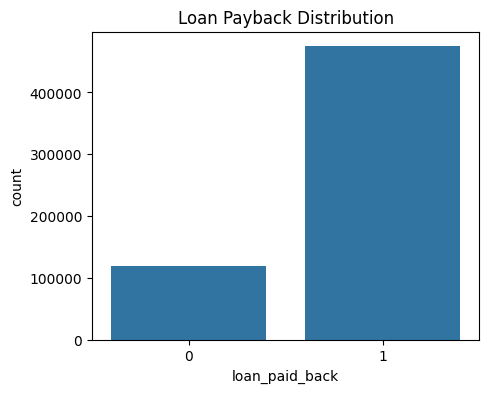

loan_paid_back
1    474494
0    119500
Name: count, dtype: int64
loan_paid_back
1   0.80
0   0.20
Name: proportion, dtype: float64


In [18]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['loan_paid_back'])
plt.title('Loan Payback Distribution')
plt.show()


print(df['loan_paid_back'].value_counts())
print(df['loan_paid_back'].value_counts(normalize=True))

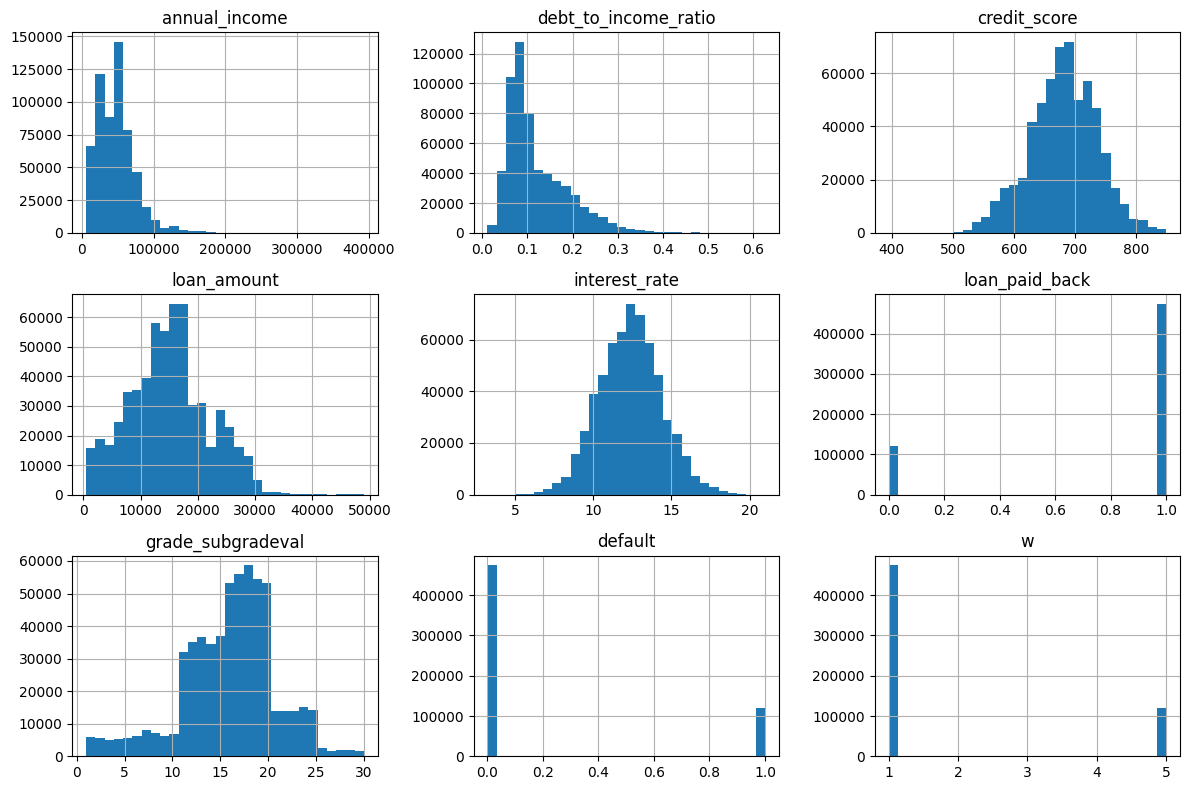

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns


df[numeric_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

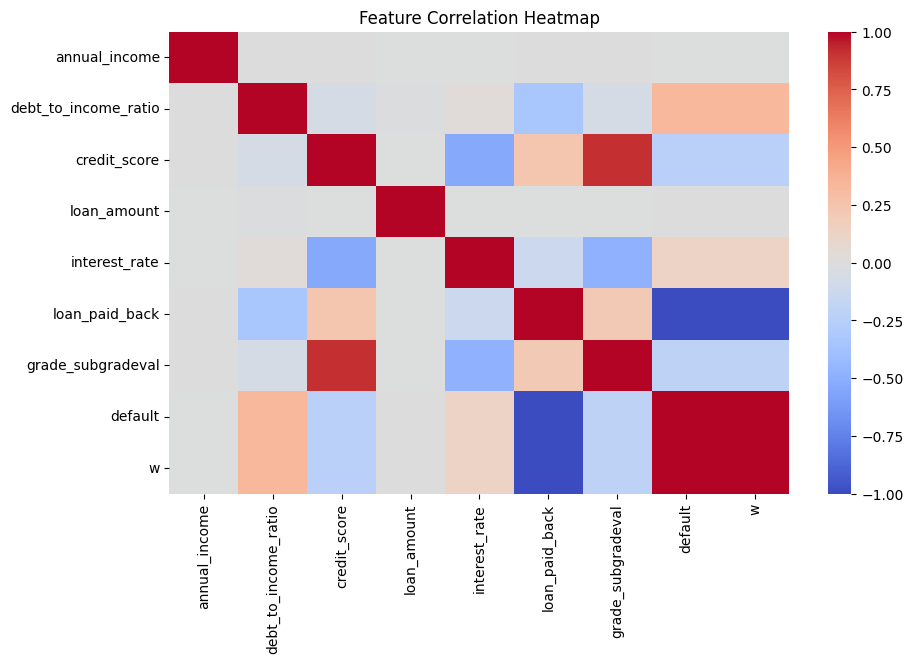

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

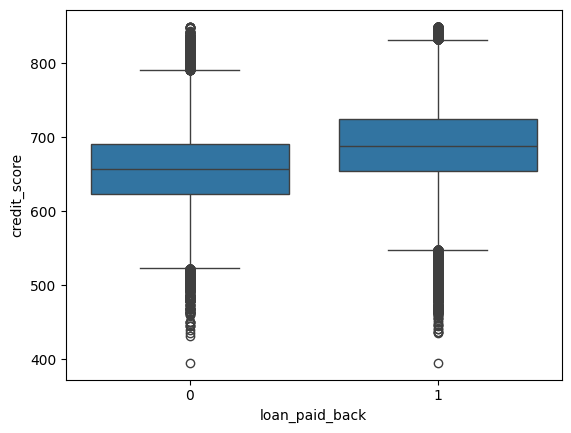

In [21]:
sns.boxplot(x='loan_paid_back', y='credit_score', data=df)
plt.show()

# ***Feature Engineering and Preprocessing***

Before training models, the following preprocessing steps are applied:
- Encoding categorical variables
- Feature scaling for models sensitive to feature magnitude
- Separating features (X) and target variable (y)

These steps ensure that the data is in a suitable format for machine learning algorithms.


## Preprocessing

In [22]:
# Variable 'debt to income ratio'
df['debt_to_income_ratio'].value_counts().head(10)

,count
debt_to_income_ratio,
0.09,11440
0.09,11160
0.10,9508
0.08,9099
0.09,8976
0.10,8647
0.07,8192
0.10,7715
0.06,7579


In [23]:
# Variable 'credit score'
df['credit_score'].value_counts().head(10)

,count
credit_score,
678,6526
661,5801
674,5793
708,5661
681,5635
672,5622
669,5618
685,5557
713,5544


In [24]:
# Variable 'interest rate'
df['interest_rate'].value_counts()

,count
interest_rate,
12.31,2638
12.52,2436
13.35,2415
12.82,2406
12.23,2362
...,...
20.64,1
7.15,1
3.20,1


In [25]:
# Variable 'gender'
df['gender'].value_counts()

,count
gender,
female,306175
male,284091
other,3728


In [26]:
# Variable 'marital status'
df['marital_status'].value_counts()

,count
marital_status,
single,288843
married,277239
divorced,21312
widowed,6600


In [27]:
# Variable 'education level'
df['education_level'].value_counts()

,count
education_level,
bachelor,279606
high_school,183592
master,93097
other,26677
phd,11022


In [28]:
# Variable 'employment status'
df['employment_status'].value_counts()

,count
employment_status,
employed,450645
unemployed,62485
self_employed,52480
retired,16453
student,11931


In [29]:
# Variable 'loan purpose'
df['loan_purpose'].value_counts()

,count
loan_purpose,
debt consolidation,324695
other,63874
car,58108
home,44118
education,36641
business,35303
medical,22806
vacation,8449


In [30]:
# Variable 'grade subgrade'
df['grade_subgrade'].value_counts()

,count
grade_subgrade,
c3,58695
c4,55957
c2,54443
c1,53363
c5,53317
d1,37029
d3,36694
d4,35097
d2,34432


In [31]:
# Variable 'loan payback'
df['loan_paid_back'].value_counts()

,count
loan_paid_back,
1,474494
0,119500


## Feature engineering

In [32]:
# Define X, y, and weights
# We drop target, and intermediate columns
X = df.drop(columns=['loan_paid_back', 'default', 'grade_subgrade', 'w'])
y = df['loan_paid_back']
weights = df['w']

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Define Preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

## Train test split

In [33]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.25, random_state=42, stratify=y
)

# ***Model Selection***

  Five classification models were evaluated in this project:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBOOST

  These models were selected to compare linear and non-linear approaches and
to assess performance improvements through ensemble learning and
hyperparameter tuning.

  Feature scaling is included in the preprocessing pipeline mainly for models such as Logistic Regression,
which are sensitive to feature magnitude. Tree-based models are not affected by scaling; however,
the same preprocessing pipeline is used for consistency and fair comparison across models.

 All preprocessing steps are applied before model training to prevent data leakage.

  These steps are implemented using pipelines to ensure correct transformation during cross-validation.

## Logistic Regression

In [34]:
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg.fit(X_train, y_train, model__sample_weight=w_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

print('Logistic Regression Results')
print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.57      0.80      0.67     29875
           1       0.94      0.85      0.89    118624

    accuracy                           0.84    148499
   macro avg       0.76      0.83      0.78    148499
weighted avg       0.87      0.84      0.85    148499

ROC-AUC: 0.9105868135936422


## Decision Tree

In [35]:
dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

dt.fit(X_train, y_train, model__sample_weight=w_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('Decision Tree Results')
print(classification_report(y_test, y_pred_dt))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_dt))

Decision Tree Results
              precision    recall  f1-score   support

           0       0.61      0.78      0.68     29875
           1       0.94      0.87      0.91    118624

    accuracy                           0.86    148499
   macro avg       0.78      0.83      0.80    148499
weighted avg       0.87      0.86      0.86    148499

ROC-AUC: 0.902000103276285


## Random Forest

In [36]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

rf.fit(X_train, y_train, model__sample_weight=w_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest Results')
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.58      0.81      0.68     29875
           1       0.95      0.85      0.90    118624

    accuracy                           0.84    148499
   macro avg       0.76      0.83      0.79    148499
weighted avg       0.87      0.84      0.85    148499

ROC-AUC: 0.9129219413289119


## Gradient Boosting

In [37]:
gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
])

gb.fit(X_train, y_train, model__sample_weight=w_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print('Gradient Boosting Results')
print(classification_report(y_test, y_pred_gb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_gb))

Gradient Boosting Results
              precision    recall  f1-score   support

           0       0.58      0.81      0.68     29875
           1       0.95      0.85      0.90    118624

    accuracy                           0.84    148499
   macro avg       0.76      0.83      0.79    148499
weighted avg       0.87      0.84      0.85    148499

ROC-AUC: 0.9157582877807788


## XGBOOST

In [38]:
# 1. Calculate Imbalance Ratio so the model learns 'Deny' cases better
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
imbalance_ratio = neg_count / pos_count

# 2. Define the tuning grid
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
}

# 3. Create the pipeline with scale_pos_weight
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss', scale_pos_weight=imbalance_ratio, random_state=42))
])

# 4. Run Randomized Search (this tests 10 different versions of the model)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(xgb_pipeline, param_distributions=param_dist,
                                   n_iter=10, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42)

print("Tuning XGBoost... please wait.")
random_search.fit(X_train, y_train)
best_xgb = random_search.best_estimator_ # This is the "Best" model

# Now use this to get predictions for your comparison table
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
print("Done!")

print('XGBoost Results')
print(classification_report(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))

Tuning XGBoost... please wait.
Done!
XGBoost Results
              precision    recall  f1-score   support

           0       0.64      0.79      0.70     29875
           1       0.94      0.89      0.91    118624

    accuracy                           0.87    148499
   macro avg       0.79      0.84      0.81    148499
weighted avg       0.88      0.87      0.87    148499

ROC-AUC: 0.9200598326642009


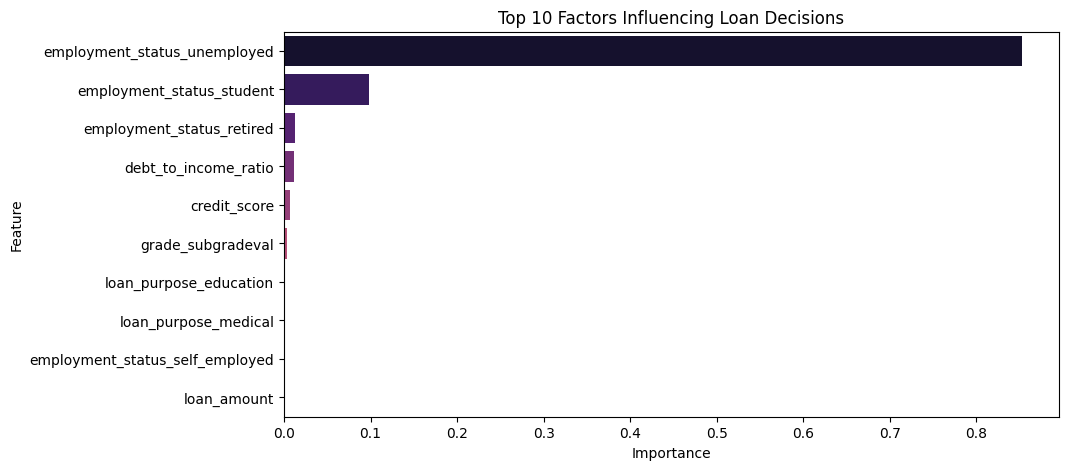

In [39]:
# Get names of features after OneHotEncoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out()
all_features = list(num_cols) + list(cat_features)

# Get importance values
importances = best_xgb.named_steps['model'].feature_importances_
feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df, hue='Feature', palette='magma', legend=False)
plt.title("Top 10 Factors Influencing Loan Decisions")
plt.show()

# ***Model Evaluation and Comparison***

Models are evaluated using consistent metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The results are compared to determine which model performs best, particularly in handling the imbalanced target variable.

## Evaluation function

In [40]:
def evaluate_model(name, y_test, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

## Compare all models

In [50]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr))
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_prob_gb))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb))

results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index = results_df.index + 1

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,XGBoost,0.87,0.94,0.89,0.91,0.92
2,Gradient Boosting,0.84,0.95,0.85,0.90,0.92
3,Random Forest,0.84,0.95,0.85,0.90,0.91
4,Logistic Regression,0.84,0.94,0.85,0.89,0.91
5,Decision Tree,0.86,0.94,0.87,0.91,0.90


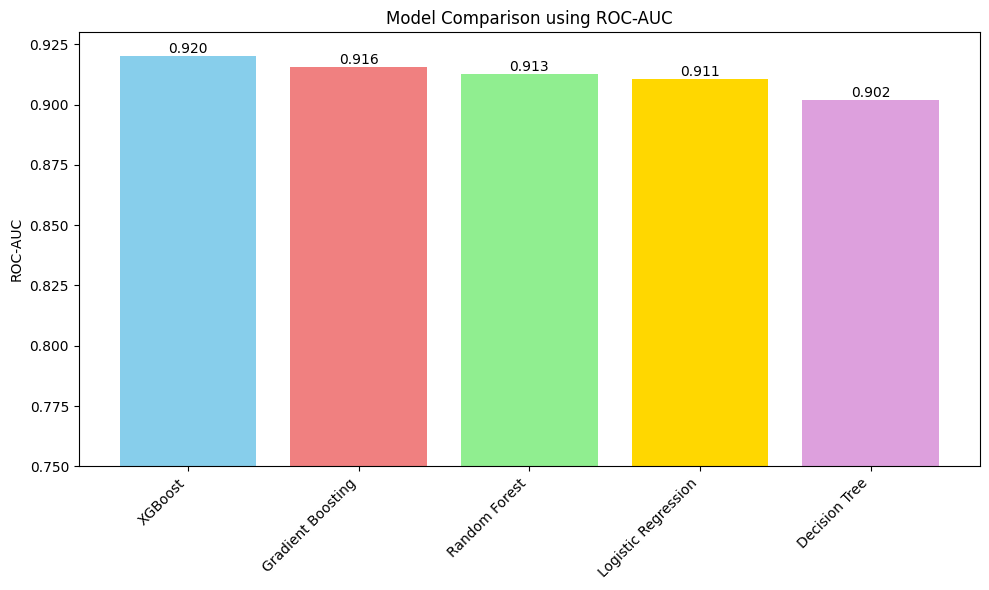

In [42]:
# Model names and scores
models = results_df['Model'].tolist()
roc_auc_scores = results_df['ROC_AUC'].tolist()

# Choose which metric to plot
scores = roc_auc_scores
metric_name = 'ROC-AUC'

plt.figure(figsize=(10, 6))
bars = plt.bar(models, scores, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum'])
plt.ylabel(metric_name)
plt.title(f'Model Comparison using {metric_name}')
plt.ylim(0.75, 0.93)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )


plt.show()

# ***Prediction function***

- Based on the evaluation results, the best-performing model is selected.  

- This project demonstrates the complete machine learning pipeline, from data cleaning and preprocessing to model comparison and selection.

In [43]:
def predict_loan_approval(model, input_data):
    input_df = pd.DataFrame([input_data])

    # Clean text
    for col in input_df.select_dtypes(include=['object']).columns:
        input_df[col] = input_df[col].str.lower().str.strip()

    # SAFEGUARD: Fix DTI if user enters 15 instead of 0.15
    if input_df['debt_to_income_ratio'].iloc[0] > 1:
        input_df['debt_to_income_ratio'] = input_df['debt_to_income_ratio'] / 100

    # Grade mapping
    grade_order = ["f5","f4","f3","f2","f1","e5","e4","e3","e2","e1",
                   "d5","d4","d3","d2","d1","c5","c4","c3","c2","c1",
                   "b5","b4","b3","b2","b1","a5","a4","a3","a2","a1"]
    grade_map = {grade: i+1 for i, grade in enumerate(grade_order)}

    if 'grade_subgrade' in input_df.columns:
        val = input_df['grade_subgrade'].iloc[0]
        input_df['grade_subgradeval'] = float(grade_map.get(val, 0))
        input_df = input_df.drop(columns=['grade_subgrade'])

    # Prediction
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        prediction = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0][1]

    print("\n" + "="*40)
    print("      LOAN APPLICATION SCORECARD")
    print("="*40)
    if prediction == 1:
        print(f"RESULT: ✅ APPROVED")
    else:
        print(f"RESULT: ❌ DENIED")
    print(f"REPAYMENT CONFIDENCE: {probability:.2%}")
    print("="*40)

In [51]:
# Define the best model is XGBOOST
# XGBoost is the best model because it achieved the highest ROC-AUC and F1-score, indicating better performance on the imbalanced loan payback dataset.
best_model = best_xgb

In [45]:
print("--- Interactive Loan Predictor ---")
user_input = {}

user_input['annual_income'] = float(input("Enter Annual Income (e.g. $50000): "))
user_input['debt_to_income_ratio'] = float(input("Enter DTI Ratio (e.g. 0.15): "))
user_input['credit_score'] = int(input("Enter Credit Score (e.g. 700): "))
user_input['loan_amount'] = float(input("Enter Loan Amount (e.g. $10000): "))
user_input['interest_rate'] = float(input("Enter Interest Rate (e.g. 10.5): "))
user_input['gender'] = input("Enter Gender (male/female): ").lower()
user_input['grade_subgrade'] = input("Enter Grade (e.g. c3): ").lower()
user_input['marital_status'] = input("Enter Marital Status (single/married): ").lower()
user_input['education_level'] = input("Enter Education (high_school/bachelor): ").lower()
user_input['employment_status'] = input("Enter Employment (employed/unemployed): ").lower()
user_input['loan_purpose'] = input("Enter Purpose (car/medical/etc): ").lower()

# Predict using XGBOOST because this is the model has the best result
predict_loan_approval(best_model, user_input)

--- Interactive Loan Predictor ---
Enter Annual Income (e.g. $50000): 800000
Enter DTI Ratio (e.g. 0.15): 0.2
Enter Credit Score (e.g. 700): 890
Enter Loan Amount (e.g. $10000): 400000
Enter Interest Rate (e.g. 10.5): 11
Enter Gender (male/female): female
Enter Grade (e.g. c3): b3
Enter Marital Status (single/married): single
Enter Education (high_school/bachelor): bachelor
Enter Employment (employed/unemployed): employed
Enter Purpose (car/medical/etc): house

      LOAN APPLICATION SCORECARD
RESULT: ✅ APPROVED
REPAYMENT CONFIDENCE: 92.70%


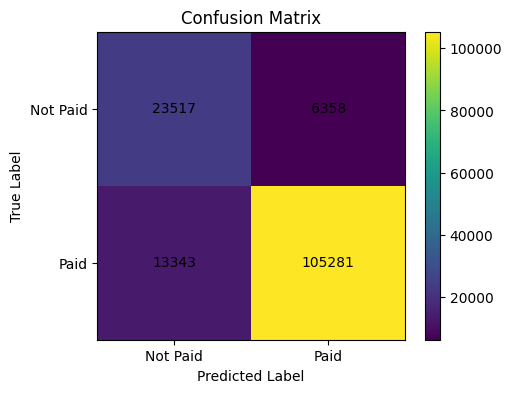

In [46]:
# Predict with the best model
y_pred = best_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()

plt.xticks([0, 1], ['Not Paid', 'Paid'])
plt.yticks([0, 1], ['Not Paid', 'Paid'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

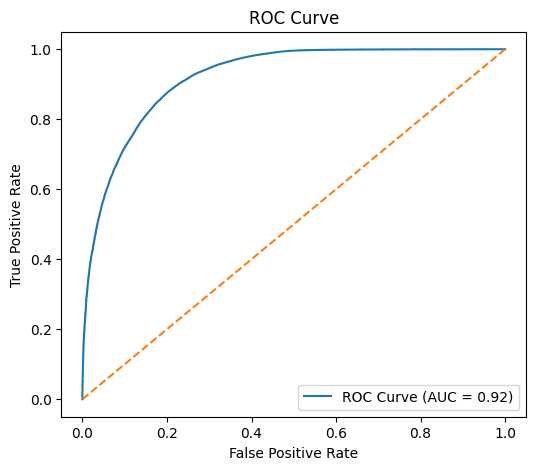

In [47]:
# Get predicted probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()
